<a href="https://colab.research.google.com/github/RothRothRoth/DeepLearning_CNN/blob/main/Road_Sign_Recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Road Sign Recognition Using Deep Learning

## Final Project

**Task:** Image Classification  
**Dataset:** Cambodia Traffic Signs Dataset (CamTSD)  
**Number of Classes:** 26  
**Approaches:**
1. CNN trained from scratch
2. ResNet-18 with frozen pretrained backbone
3. ResNet-18 with full fine-tuning

### Objective
Develop and compare deep learning approaches for recognizing Cambodian traffic signs from images.

### Evaluation
The approaches will be evaluated using the same held-out test set and appropriate classification metrics, including accuracy, precision, recall, F1-score, and confusion matrices.

In [1]:
# ============================================
# Cell 2: Environment & Reproducibility
# ============================================

import os
import random
import numpy as np
import torch

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
# ============================================
# Cell 3: Google Drive & Project Paths
# ============================================

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive", force_remount=True)

# Main project directory
PROJECT_DIR = "/content/drive/MyDrive/Road_Sign_Recognition_CNN"

# Project subdirectories
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
RAW_DIR = os.path.join(DATASET_DIR, "raw")
PROCESSED_DIR = os.path.join(DATASET_DIR, "processed")
TEST_DIR = os.path.join(DATASET_DIR, "test")

MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# Create required folders if they don't exist
for folder in [
    PROJECT_DIR,
    DATASET_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    TEST_DIR,
    MODELS_DIR,
    RESULTS_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nProject folders:")
for folder in [
    DATASET_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    TEST_DIR,
    MODELS_DIR,
    RESULTS_DIR
]:
    print("✓", folder)

Mounted at /content/drive
Project directory:
/content/drive/MyDrive/Road_Sign_Recognition_CNN

Project folders:
✓ /content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset
✓ /content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/raw
✓ /content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/processed
✓ /content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/test
✓ /content/drive/MyDrive/Road_Sign_Recognition_CNN/models
✓ /content/drive/MyDrive/Road_Sign_Recognition_CNN/results


In [3]:
# ============================================
# Cell 4: Dataset Verification
# ============================================

import os

# Check processed dataset
print("Processed dataset exists:", os.path.exists(PROCESSED_DIR))

# Get class folders
class_folders = sorted([
    folder for folder in os.listdir(PROCESSED_DIR)
    if os.path.isdir(os.path.join(PROCESSED_DIR, folder))
])

print("\nNumber of classes:", len(class_folders))

print("\nClasses:")
for i, class_name in enumerate(class_folders, start=1):
    print(f"{i:02d}. {class_name}")

# Count images in each class
print("\nImages per class:")

total_images = 0

for class_name in class_folders:
    class_path = os.path.join(PROCESSED_DIR, class_name)

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    total_images += image_count

    print(f"{class_name:30s} : {image_count}")

print("\n--------------------------------")
print("Total images:", total_images)
print("Total classes:", len(class_folders))
print("--------------------------------")

Processed dataset exists: True

Number of classes: 26

Classes:
01. 30_SPEED_LIMIT
02. 40_SPEED_LIMIT
03. 60_SPEED_LIMIT
04. 80_SPEED_LIMIT
05. CARRIAGE_WAY_NARROWS
06. CHILDREN_CROSSING
07. CROSS_ROAD
08. DIRECTION
09. END_SPEED_LIMIT
10. HOSPITAL
11. KEEP_RIGHT
12. KM_POST
13. LEFT_BEND
14. NO_ENTRY
15. NO_HORN
16. NO_PARKING
17. NO_UTURN
18. PEDESTRAIN_CROSSING
19. PEDESTRAIN_CR_AREA
20. PRIORITY_ROAD
21. RIGHT_BEND
22. ROAD_JUNCTION_ON_THE_LEFT
23. ROAD_JUNCTION_ON_THE_RIGHT
24. SLOW_DOWN
25. STAGGERED_JUNCTION_RL
26. U_TURN

Images per class:
30_SPEED_LIMIT                 : 30
40_SPEED_LIMIT                 : 94
60_SPEED_LIMIT                 : 48
80_SPEED_LIMIT                 : 37
CARRIAGE_WAY_NARROWS           : 29
CHILDREN_CROSSING              : 188
CROSS_ROAD                     : 42
DIRECTION                      : 152
END_SPEED_LIMIT                : 52
HOSPITAL                       : 53
KEEP_RIGHT                     : 327
KM_POST                        : 738
LEFT_BEND 

In [4]:
# ============================================
# Cell 5: Locate Original Dataset
# ============================================

KAGGLE_DIR = "/kaggle/input/cambodia-traffic-signs-dataset"

print("Dataset exists:", os.path.exists(KAGGLE_DIR))

if os.path.exists(KAGGLE_DIR):
    print("\nDataset contents:")
    for item in sorted(os.listdir(KAGGLE_DIR)):
        print("✓", item)

    IMAGE_DIR = os.path.join(KAGGLE_DIR, "images")
    DATA_DIR = os.path.join(KAGGLE_DIR, "data")
    JSON_PATH = os.path.join(DATA_DIR, "CAM_TSR_v3_json.json")

    print("\nImages folder exists:", os.path.exists(IMAGE_DIR))
    print("Data folder exists:", os.path.exists(DATA_DIR))
    print("Annotation JSON exists:", os.path.exists(JSON_PATH))
else:
    print("\n⚠️ Original Kaggle dataset is not available in this Colab runtime.")

Dataset exists: False

⚠️ Original Kaggle dataset is not available in this Colab runtime.


In [5]:
# ============================================
# Cell 6: Check Raw Dataset
# ============================================

print("Raw dataset folder:")
print(RAW_DIR)

print("\nContents:")

if os.path.exists(RAW_DIR):
    items = os.listdir(RAW_DIR)

    if len(items) == 0:
        print("⚠️ Raw folder is empty.")
    else:
        for item in sorted(items):
            print("✓", item)
else:
    print("⚠️ Raw folder does not exist.")

Raw dataset folder:
/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/raw

Contents:
✓ archive.zip
✓ data
✓ images
✓ labels
✓ via.html


In [9]:
# ============================================
# Cell 8: Extract Original Dataset
# ============================================

import zipfile
import os
import shutil

# Find ZIP file directly from RAW_DIR
zip_files = [
    os.path.join(RAW_DIR, f)
    for f in os.listdir(RAW_DIR)
    if f.lower().endswith(".zip")
]

if len(zip_files) == 0:
    raise FileNotFoundError("No ZIP file found in the raw dataset folder.")

ZIP_PATH = zip_files[0]

# Extract to fast Colab local storage
LOCAL_RAW_DIR = "/content/road_sign_dataset"

print("Extracting:")
print(ZIP_PATH)

# Remove old extraction if it exists
if os.path.exists(LOCAL_RAW_DIR):
    shutil.rmtree(LOCAL_RAW_DIR)

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(LOCAL_RAW_DIR)

print("\n✅ Extraction complete!")

print("\nDataset contents:")
for item in sorted(os.listdir(LOCAL_RAW_DIR)):
    print("📁", item)

Extracting:
/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/raw/archive.zip

✅ Extraction complete!

Dataset contents:
📁 data
📁 images
📁 labels
📁 via.html


In [14]:
# ============================================
# Cell 9: Verify Original Dataset
# ============================================

IMAGE_DIR = os.path.join(LOCAL_RAW_DIR, "images")
LABEL_DIR = os.path.join(LOCAL_RAW_DIR, "labels")
ANNOTATION_DIR = os.path.join(LOCAL_RAW_DIR, "data")

# Find annotation JSON files
json_files = [
    f for f in os.listdir(ANNOTATION_DIR)
    if f.lower().endswith(".json")
]

# Count images
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Count label files
label_files = [
    f for f in os.listdir(LABEL_DIR)
    if f.lower().endswith(".txt")
]

print("========== ORIGINAL DATASET ==========")
print("Images:", len(image_files))
print("YOLO label files:", len(label_files))
print("JSON annotation files:", len(json_files))

print("\nJSON files:")
for f in json_files:
    print("✓", f)

print("\nImage folder:", IMAGE_DIR)
print("Label folder:", LABEL_DIR)
print("Annotation folder:", ANNOTATION_DIR)

========== ORIGINAL DATASET ==========
Images: 2766
YOLO label files: 2757
JSON annotation files: 8

JSON files:
✓ CAM_TSR_v3.json
✓ CAM_TSR_v2.json
✓ CAM_TSR_v3_json_state.json
✓ CAM_TSR_v2_json.json
✓ CAM_TSR.json
✓ CAM_TSR_json.json
✓ CAM_TSR_v3_json.json
✓ CAM_TSR_attributes.json

Image folder: /content/road_sign_dataset/images
Label folder: /content/road_sign_dataset/labels
Annotation folder: /content/road_sign_dataset/data


In [11]:
# ============================================
# Cell 10: Inspect Traffic Sign Annotations
# ============================================

import json

JSON_PATH = os.path.join(
    ANNOTATION_DIR,
    "CAM_TSR_v3_json.json"
)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    annotations = json.load(f)

print("Annotation file loaded successfully!")
print("Type:", type(annotations))

if isinstance(annotations, dict):
    print("Number of records:", len(annotations))
    print("\nFirst record:")
    first_key = next(iter(annotations))
    print("Key:", first_key)
    print("Value:", annotations[first_key])
else:
    print("Number of records:", len(annotations))

Annotation file loaded successfully!
Type: <class 'dict'>
Number of records: 2757

First record:
Key: GX010109.MP4_snapshot_00.10.234.jpg1255446
Value: {'filename': 'GX010109.MP4_snapshot_00.10.234.jpg', 'size': 579503, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 2744, 'y': 655, 'width': 162, 'height': 156}, 'region_attributes': {'Object': 'Traffic Sign', 'Class': 'Warning', 'Name': 'CHILDREN CROSSING', 'Status': 'Good'}}, {'shape_attributes': {'name': 'rect', 'x': 2754, 'y': 807, 'width': 140, 'height': 132}, 'region_attributes': {'Object': 'Traffic Sign', 'Class': 'Prohibitory', 'Name': '40 SPEED LIMIT', 'Status': 'Good'}}], 'file_attributes': {}}


In [12]:
# Check annotation statistics

total_regions = 0
undefined_count = 0
images_with_multiple_signs = 0

for record in annotations.values():
    regions = record.get("regions", [])

    total_regions += len(regions)

    if len(regions) > 1:
        images_with_multiple_signs += 1

    for region in regions:
        attrs = region.get("region_attributes", {})
        if attrs.get("Name") == "UNDEFINED":
            undefined_count += 1

print("Total traffic-sign annotations:", total_regions)
print("Images containing multiple signs:", images_with_multiple_signs)
print("UNDEFINED annotations:", undefined_count)

Total traffic-sign annotations: 3490
Images containing multiple signs: 627
UNDEFINED annotations: 117


In [15]:
# ============================================
# Cell 10: Inspect Traffic Sign Annotations
# ============================================

import json

JSON_PATH = os.path.join(
    ANNOTATION_DIR,
    "CAM_TSR_v3_json.json"
)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    annotations = json.load(f)

print("Annotation file loaded successfully!")
print("Type:", type(annotations))

if isinstance(annotations, dict):
    print("Number of records:", len(annotations))

    print("\nFirst record:")
    first_key = next(iter(annotations))

    print("Key:", first_key)
    print("Value:", annotations[first_key])
else:
    print("Number of records:", len(annotations))

Annotation file loaded successfully!
Type: <class 'dict'>
Number of records: 2757

First record:
Key: GX010109.MP4_snapshot_00.10.234.jpg1255446
Value: {'filename': 'GX010109.MP4_snapshot_00.10.234.jpg', 'size': 579503, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 2744, 'y': 655, 'width': 162, 'height': 156}, 'region_attributes': {'Object': 'Traffic Sign', 'Class': 'Warning', 'Name': 'CHILDREN CROSSING', 'Status': 'Good'}}, {'shape_attributes': {'name': 'rect', 'x': 2754, 'y': 807, 'width': 140, 'height': 132}, 'region_attributes': {'Object': 'Traffic Sign', 'Class': 'Prohibitory', 'Name': '40 SPEED LIMIT', 'Status': 'Good'}}], 'file_attributes': {}}


In [17]:
# ============================================
# Cell 11: Create Fixed Train / Validation / Test Split
# ============================================

import pandas as pd
from sklearn.model_selection import train_test_split

# Collect all processed images
dataset_records = []

for class_name in class_folders:
    class_path = os.path.join(PROCESSED_DIR, class_name)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            dataset_records.append({
                "filepath": os.path.join(class_path, filename),
                "filename": filename,
                "class_name": class_name
            })

dataset_df = pd.DataFrame(dataset_records)

print("Total images:", len(dataset_df))
print("Total classes:", dataset_df["class_name"].nunique())

# --------------------------------------------
# First split: 70% train, 30% temporary
# --------------------------------------------

train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    random_state=SEED,
    stratify=dataset_df["class_name"]
)

# --------------------------------------------
# Second split: 15% validation, 15% test
# --------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["class_name"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n========== DATA SPLIT ==========")
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

print("\nExpected approximately:")
print("Train: 70%")
print("Validation: 15%")
print("Test: 15%")
# ============================================
# Save fixed split for reproducibility
# ============================================

SPLIT_DIR = os.path.join(PROCESSED_DIR, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(
    os.path.join(SPLIT_DIR, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SPLIT_DIR, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SPLIT_DIR, "test.csv"),
    index=False
)

print("\n✅ Fixed dataset splits saved to:")
print(SPLIT_DIR)

Total images: 3070
Total classes: 26

========== DATA SPLIT ==========
Training: 2149
Validation: 460
Testing: 461
Total: 3070

Expected approximately:
Train: 70%
Validation: 15%
Test: 15%

✅ Fixed dataset splits saved to:
/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/processed/splits


In [18]:
# ============================================
# Cell 12: PyTorch Dataset & DataLoaders
# ============================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --------------------------------------------
# Image configuration
# --------------------------------------------

IMAGE_SIZE = 224
BATCH_SIZE = 32

# ImageNet normalization
# Used because ResNet-18 pretrained weights
# were trained with ImageNet normalization.
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# --------------------------------------------
# Training transformations
# --------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Mild augmentation suitable for traffic signs.
    # We intentionally DO NOT use horizontal flipping
    # because left/right traffic signs can change meaning.
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# --------------------------------------------
# Validation / Test transformations
# --------------------------------------------

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


# ============================================
# Custom Dataset
# ============================================

class TrafficSignDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        # Convert class names to numerical IDs
        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(class_folders)
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["filepath"]
        class_name = row["class_name"]

        # Open image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert class name → integer
        label = self.class_to_idx[class_name]

        return image, label


# ============================================
# Create datasets
# ============================================

train_dataset = TrafficSignDataset(
    train_df,
    transform=train_transform
)

val_dataset = TrafficSignDataset(
    val_df,
    transform=eval_transform
)

test_dataset = TrafficSignDataset(
    test_df,
    transform=eval_transform
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))


# ============================================
# Create DataLoaders
# ============================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders created successfully!")
print("Batch size:", BATCH_SIZE)
print("Image size:", IMAGE_SIZE)

Training samples: 2149
Validation samples: 460
Testing samples: 461

DataLoaders created successfully!
Batch size: 32
Image size: 224


In [19]:
# ============================================
# Cell 13: Verify DataLoader
# ============================================

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

print("\nFirst 10 labels:")
print(labels[:10].tolist())

print("\nExpected image shape:")
print(f"[{BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Minimum pixel value: -2.1179039478302
Maximum pixel value: 2.640000104904175

First 10 labels:
[10, 5, 21, 17, 4, 10, 5, 11, 10, 6]

Expected image shape:
[32, 3, 224, 224]


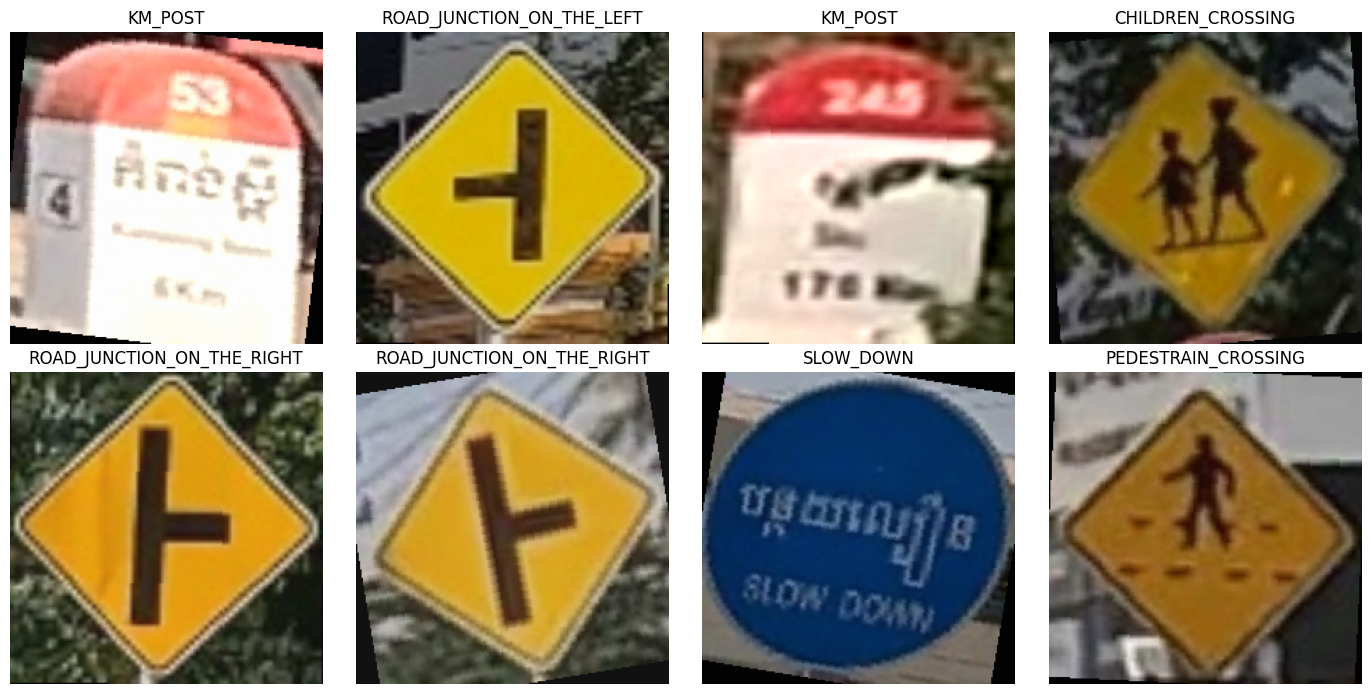

In [20]:
# ============================================
# Cell 14: Visualize Training Samples
# ============================================

import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# Undo normalization for visualization
mean = torch.tensor(MEAN).view(3, 1, 1)
std = torch.tensor(STD).view(3, 1, 1)

images_display = images[:8].cpu() * std + mean
images_display = torch.clamp(images_display, 0, 1)

plt.figure(figsize=(14, 7))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    image = images_display[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(class_folders[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
!git add README.md
!git commit -m "Update README"
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
